# Telco Customer Churn — Modeling

Goal: Train and compare classification models starting with the simplest 
first. Complexity is only added when simpler models fall short.

The progression follows the bias-variance tradeoff:

1. Logistic Regression (High bias, low variance ), answers: "What's the simplest signal in the data?"
2. Random Forest (Lower bias, controlled variance ), answers: "What nonlinear structure exists?"
3. XGBoost (Low bias, optimized variance), answers: "How far can we push performance?"

Each model builds on the last. If logistic regression performs well, 
the data has mostly linear relationships and complexity is not needed. 
If random forest meaningfully improves on it, nonlinear structure exists 
worth capturing. XGBoost is only added if random forest justifies it.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.metrics import precision_recall_curve


In [9]:
X_train = pd.read_pickle("../data/X_train.pkl")
X_test  = pd.read_pickle("../data/X_test.pkl")
y_train = pd.read_pickle("../data/y_train.pkl")
y_test  = pd.read_pickle("../data/y_test.pkl")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (5634, 25)
X_test:  (1409, 25)


## Model 1: Logistic Regression — baseline

Starting with the simplest possible logistic regression — no class 
weight adjustment, no regularization tuning, default settings only.

This is our true baseline. We want to know what the data gives us 
naturally before adding any corrections. We will only add class_weight 
balancing if recall for churners is unacceptably low.

In [10]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)

print(f"ROC-AUC: {lr_auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Churn', 'Churn']))

ROC-AUC: 0.842

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## Logistic Regression baseline results

ROC-AUC: 0.842 — strong overall discrimination ability. The model 
is meaningfully separating churners from non-churners.

The critical number is Churn recall: 0.51
This means the model is only catching 51% of actual churners — 
it is missing nearly half the customers who will leave.

In business terms: out of every 100 customers about to churn, 
we correctly flag 51 and completely miss 49. Those 49 missed 
churners receive no intervention and are lost.

Precision of 0.66 means when we do flag someone as a churner, 
we are right 66% of the time — acceptable but not great.

Conclusion: ROC-AUC is strong but recall is too low for a 
business use case where missing a churner is costly. Before 
adding model complexity, we will first try adjusting the 
classification threshold.

In [11]:
lr_pred_adjusted = (lr_prob >= 0.3).astype(int)

print("Results with threshold = 0.3:")
print(classification_report(y_test, lr_pred_adjusted,
      target_names=['No Churn', 'Churn']))

Results with threshold = 0.3:
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



## Threshold adjustment: 0.5 → 0.3

Lowering the classification threshold from 0.5 to 0.3 means we flag 
a customer as churner if the model gives them 30%+ churn probability 
instead of 50%+.

| Metric | Threshold 0.5 | Threshold 0.3 | Change |
|---|---|---|---|
| ROC-AUC | 0.842 | 0.842 | no change |
| Churn Recall | 0.51 | 0.75 | +0.24 |
| Churn Precision | 0.66 | 0.53 | -0.13 |
| Churn F1 | 0.58 | 0.62 | +0.04 |
| Accuracy | 0.80 | 0.76 | -0.04 |

ROC-AUC stays the same — threshold does not affect the model itself, 
only how we convert probabilities into decisions.

The tradeoff: we catch 24% more churners but generate more false alarms.
In business terms — for every 100 actual churners:
- Threshold 0.5: catch 51, miss 49
- Threshold 0.3: catch 75, miss 25

The cost of missing a churner (lost revenue) almost always exceeds 
the cost of a false alarm (wasted retention offer). Threshold 0.3 
is the better business decision.

To achieve recall ~0.80:
  Threshold: 0.25
  Precision: 0.50
  Recall:    0.80


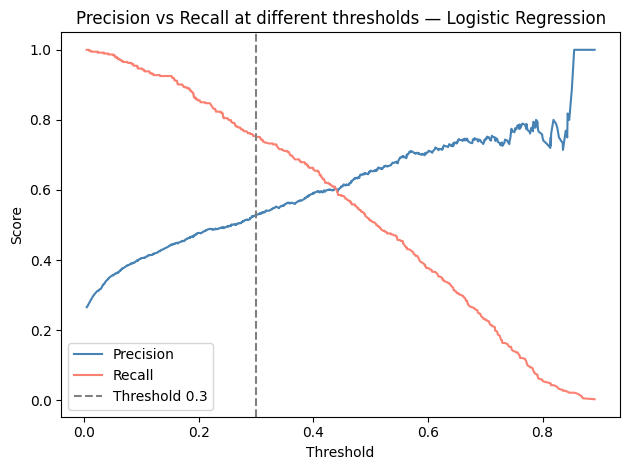

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, lr_prob)

target_recall = 0.80
idx = np.argmin(np.abs(recall - target_recall))

print(f"To achieve recall ~0.80:")
print(f"  Threshold: {thresholds[idx]:.2f}")
print(f"  Precision: {precision[idx]:.2f}")
print(f"  Recall:    {recall[idx]:.2f}")

fig, ax = plt.subplots()
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall[:-1], label='Recall', color='salmon')
ax.axvline(x=0.3, color='gray', linestyle='--', label='Threshold 0.3')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall at different thresholds — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/09_precision_recall_threshold.png')
plt.show()

In [14]:
lr_pred_025 = (lr_prob >= 0.25).astype(int)

print("Results with threshold = 0.25:")
print(classification_report(y_test, lr_pred_025,
      target_names=['No Churn', 'Churn']))

Results with threshold = 0.25:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.79      1035
       Churn       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409



## Logistic Regression — threshold summary

Three thresholds compared:

| Threshold | Recall | Precision | F1 | Accuracy |
|---|---|---|---|---|
| 0.50 (default) | 0.51 | 0.66 | 0.58 | 0.80 |
| 0.30 | 0.75 | 0.53 | 0.62 | 0.76 |
| 0.25 | 0.80 | 0.50 | 0.62 | 0.74 |

Selected threshold: 0.30
Reasoning: 0.25 gains only 5% more recall but drops precision to 
exactly 50% — meaning half of all churn flags are false alarms. 
Threshold 0.30 gives a better balance: 75% recall at 53% precision 
with a 4% higher accuracy. The marginal recall gain at 0.25 does 
not justify the precision loss.

Logistic Regression final score at threshold 0.30:
- ROC-AUC: 0.842
- Recall:  0.75
- F1:      0.62

This is our baseline to beat with Random Forest.